<a href="https://colab.research.google.com/github/dmareee/skripsi/blob/main/Copy_of_skripsi_multimodal_predict_osteo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Lib and Data

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


After running the above cell and following the authentication steps, your Google Drive will be mounted at `/content/drive`. You can then navigate to your files. For example, if you have a file named `my_data.csv` in a folder named `Colab Notebooks` on your Google Drive, its path would typically be `/content/drive/MyDrive/Colab Notebooks/my_data.csv`.

To verify the mount and list files in your Drive, you can use the following shell command:

In [ ]:
!ls /content/drive/MyDrive/skripsi

'draf_skripsi_bab1_osteo predict.docx'	'Osteoporosis Knee X-ray'
 osseus_dataset.csv


To load X-ray images, let's first inspect the contents of the `Osteoporosis Knee X-ray` directory to understand the file structure. This will help determine the best way to load and link them with the patient data.

In [ ]:
import os

xray_image_dir = '/content/drive/MyDrive/skripsi/Osteoporosis Knee X-ray'

# List contents of the directory
if os.path.exists(xray_image_dir):
    print(f"Contents of {xray_image_dir}:")
    for item in os.listdir(xray_image_dir):
        print(item)
else:
    print(f"Directory not found: {xray_image_dir}")


Contents of /content/drive/MyDrive/skripsi/Osteoporosis Knee X-ray:
normal
osteoporosis
osteopenia
patient details.xlsx


The directory structure indicates that images are categorized by diagnosis. Let's load the `patient details.xlsx` file to see if it contains information that links to the images or provides additional patient details.

Once you know the path to your file, you can load it using pandas, for example:

# Data Understanding

## Load X-Ray Images

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zipfile,os
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras import layers, models, regularizers

# Mengabaikan peringatan
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [ ]:
base_dir = xray_image_dir

train_dir = os.path.join(base_dir)

print(f"Base Directory: {base_dir}")
print(f"Train Directory: {train_dir}")

Base Directory: /content/drive/MyDrive/skripsi/Osteoporosis Knee X-ray
Train Directory: /content/drive/MyDrive/skripsi/Osteoporosis Knee X-ray


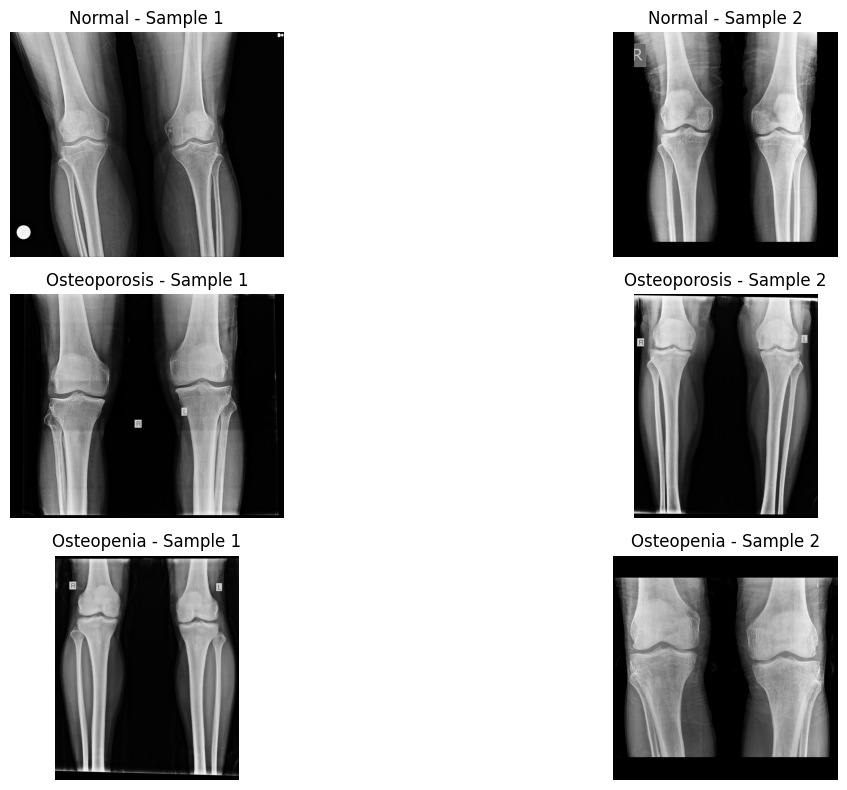

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

xray_image_dir = '/content/drive/MyDrive/skripsi/Osteoporosis Knee X-ray'

diagnosis_categories = ['normal', 'osteoporosis', 'osteopenia']
sample_images = {}

for category in diagnosis_categories:
    category_path = os.path.join(xray_image_dir, category)
    if os.path.exists(category_path):
        # Get a list of all files in the directory
        image_files = [f for f in os.listdir(category_path) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp'))]
        # Select up to 2 random images for display
        if len(image_files) > 0:
            # Shuffle and take a few samples, or just take the first few if not enough
            import random
            random.shuffle(image_files)
            sample_images[category] = [os.path.join(category_path, f) for f in image_files[:2]]
        else:
            print(f"No image files found in {category_path}")
    else:
        print(f"Directory not found: {category_path}")

# Display the sample images
plt.figure(figsize=(15, 8))
plot_index = 1
for category, images in sample_images.items():
    for img_path in images:
        try:
            img = Image.open(img_path)
            plt.subplot(len(diagnosis_categories), 2, plot_index) # Max 2 images per category
            plt.imshow(img, cmap='gray') # X-rays are typically grayscale
            plt.title(f"{category.capitalize()} - Sample {plot_index % 2 if plot_index % 2 != 0 else 2}")
            plt.axis('off')
            plot_index += 1
        except Exception as e:
            print(f"Could not load image {img_path}: {e}")

plt.tight_layout()
plt.show()

## Patient Data

In [ ]:
patient_details_path = '/content/drive/MyDrive/skripsi/Osteoporosis Knee X-ray/patient details.xlsx'
df = pd.read_excel(patient_details_path)
display(df.head())

,S.No,Patient Id,Joint Pain:,Gender,Age,Menopause Age,height (meter),Weight (KG),Smoker,Alcoholic,...,Family History of Osteoporosis,Maximum Walking distance (km),Daily Eating habits,Medical History,T-score Value,Z-Score Value,BMI:,Site,Obesity,Diagnosis
0,1.0,OP1,yes,male,65.0,NaN,1.64592,65.0,yes,no,...,no,0.2,normal,normal,-1.98,0.73,23.993627,knee,normal weight,osteopenia
1,2.0,OP2,yes,female,54.0,46,1.67640,78.0,no,no,...,no,1.0,normal,"G.B rem, B.P",-2.26,-2.71,27.754876,knee,over weight,osteopenia
2,3.0,OP3,yes,female,49.0,43,1.37160,59.0,no,no,...,no,1.0,low protiens,no,-1.92,-1.51,31.361517,knee,obesity,osteopenia
3,4.0,OP4,yes,female,57.0,40,1.52400,72.0,no,no,...,no,2.0,low fats,uterus removed,-2.23,-1.13,31.000062,knee,obesity,osteopenia
4,5.0,OP5,yes,female,40.0,NaN,1.49352,54.0,no,no,...,no,2.0,normal,depression,-1.81,-1.05,24.208711,knee,normal weight,osteopenia


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   S.No                            240 non-null    float64
 1   Patient Id                      240 non-null    object 
 2   Joint Pain:                     240 non-null    object 
 3   Gender                          240 non-null    object 
 4   Age                             243 non-null    float64
 5   Menopause Age                   86 non-null     object 
 6   height  (meter)                 243 non-null    float64
 7   Weight (KG)                     243 non-null    float64
 8   Smoker                          240 non-null    object 
 9   Alcoholic                       240 non-null    object 
 10  Diabetic                        240 non-null    object 
 11  Hypothyroidism                  240 non-null    object 
 12  Number of Pregnancies           124 

* S.No: A serial number or index for each entry.
* Patient Id: A unique identifier for each patient.
* Joint Pain: Indicates if the patient experiences joint pain.
* Gender: The gender of the patient.
* Age: The age of the patient.
* Menopause Age: The age at which female patients experienced menopause (if applicable).
* height (meter): The patient's height in meters.
* Weight (KG): The patient's weight in kilograms.
* Smoker: Indicates if the patient is a smoker.
* Alcoholic: Indicates if the patient consumes alcohol.
* Diabetic: Indicates if the patient is diabetic.
* Hypothyroidism: Indicates if the patient has hypothyroidism.
* Number of Pregnancies: The number of pregnancies for female patients.
* Seizer Disorder: Indicates if the patient has a seizure disorder.
* Estrogen Use: Indicates if the patient uses estrogen.
* Occupation: The patient's occupation.
* History of Fracture: Indicates if the patient has a history of fractures.
* Dialysis: Indicates if the patient is undergoing dialysis.
* Family History of Osteoporosis: Indicates if there is a family history of osteoporosis.
* Maximum Walking distance (km): The maximum walking distance in kilometers.
* Daily Eating habits: Description of the patient's daily eating habits.
* Medical History: Any relevant medical history of the patient.
* T-score Value: A measure used to diagnose osteoporosis, representing the bone mineral density compared to a healthy young adult.
* Z-Score Value: A measure comparing the bone mineral density to individuals of the same age, sex, and ethnicity.
* BMI: The Body Mass Index of the patient.
* Site: The site of measurement (e.g., knee).
* Obesity: Indicates the patient's obesity status.
* Diagnosis: The diagnosis related to bone health (e.g., osteopenia, normal, osteoporosis).

In [ ]:
df.drop(columns=['S.No'], inplace=True)

In [ ]:
def clean_col_name(col_name):
    # Convert to lowercase
    cleaned_name = col_name.lower()
    # Replace spaces with underscores
    cleaned_name = cleaned_name.replace(' ', '_')
    # Remove specific special characters
    cleaned_name = cleaned_name.replace(':', '')
    cleaned_name = cleaned_name.replace('(', '')
    cleaned_name = cleaned_name.replace(')', '')
    cleaned_name = cleaned_name.replace('-', '')
    cleaned_name = cleaned_name.replace('%', 'pct') # Example for '%' if it were there
    # Remove any double underscores that might result from cleaning
    cleaned_name = cleaned_name.replace('__', '_')
    # Remove trailing/leading underscores
    cleaned_name = cleaned_name.strip('_')
    return cleaned_name

# Generate new column names
new_columns = {col: clean_col_name(col) for col in df.columns}

# Rename the columns in the DataFrame
df.rename(columns=new_columns, inplace=True)

# Display the first few rows with new column names
display(df.head())

,patient_id,joint_pain,gender,age,menopause_age,height_meter,weight_kg,smoker,alcoholic,diabetic,...,family_history_of_osteoporosis,maximum_walking_distance_km,daily_eating_habits,medical_history,tscore_value,zscore_value,bmi,site,obesity,diagnosis
0,OP1,yes,male,65.0,NaN,1.64592,65.0,yes,no,no,...,no,0.2,normal,normal,-1.98,0.73,23.993627,knee,normal weight,osteopenia
1,OP2,yes,female,54.0,46,1.67640,78.0,no,no,no,...,no,1.0,normal,"G.B rem, B.P",-2.26,-2.71,27.754876,knee,over weight,osteopenia
2,OP3,yes,female,49.0,43,1.37160,59.0,no,no,no,...,no,1.0,low protiens,no,-1.92,-1.51,31.361517,knee,obesity,osteopenia
3,OP4,yes,female,57.0,40,1.52400,72.0,no,no,no,...,no,2.0,low fats,uterus removed,-2.23,-1.13,31.000062,knee,obesity,osteopenia
4,OP5,yes,female,40.0,NaN,1.49352,54.0,no,no,no,...,no,2.0,normal,depression,-1.81,-1.05,24.208711,knee,normal weight,osteopenia


In [ ]:
df.columns

Index(['patient_id', 'joint_pain', 'gender', 'age', 'menopause_age',
       'height_meter', 'weight_kg', 'smoker', 'alcoholic', 'diabetic',
       'hypothyroidism', 'number_of_pregnancies', 'seizer_disorder',
       'estrogen_use', 'occupation', 'history_of_fracture', 'dialysis',
       'family_history_of_osteoporosis', 'maximum_walking_distance_km',
       'daily_eating_habits', 'medical_history', 'tscore_value',
       'zscore_value', 'bmi', 'site', 'obesity', 'diagnosis'],
      dtype='object')

In [ ]:
df.describe(include='all').style.background_gradient('Greens_r')

,patient_id,joint_pain,gender,age,menopause_age,height_meter,weight_kg,smoker,alcoholic,diabetic,hypothyroidism,number_of_pregnancies,seizer_disorder,estrogen_use,occupation,history_of_fracture,dialysis,family_history_of_osteoporosis,maximum_walking_distance_km,daily_eating_habits,medical_history,tscore_value,zscore_value,bmi,site,obesity,diagnosis
count,240,240,240,243.000000,86.000000,243.000000,243.000000,240,240,240,240,124.000000,240,240,236,240,240,240,239.000000,238,240,240.000000,240.000000,240.000000,240,240,240
unique,240,2,2,nan,21.000000,nan,nan,2,1,2,2,nan,2,2,29,47,2,2,nan,27,82,nan,nan,nan,1,5,3
top,OP1,yes,female,nan,48.000000,nan,nan,no,no,no,no,nan,no,no,h.wife,no,no,no,nan,normal,no,nan,nan,nan,knee,over weight,osteopenia
freq,1,238,132,nan,26.000000,nan,nan,199,240,228,206,nan,232,229,115,169,239,174,nan,186,113,nan,nan,nan,240,112,154
mean,nan,nan,nan,51.135991,nan,1.585779,69.053738,nan,nan,nan,nan,3.443548,nan,nan,nan,nan,nan,nan,1.940167,nan,nan,-1.833625,-1.327292,27.590448,nan,nan,nan
std,nan,nan,nan,13.231022,nan,0.097444,9.885774,nan,nan,nan,nan,1.466717,nan,nan,nan,nan,nan,nan,1.991257,nan,nan,0.687243,0.675927,4.043308,nan,nan,nan
min,nan,nan,nan,17.000000,nan,1.371600,39.000000,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,0.100000,nan,nan,-2.990000,-2.990000,16.139658,nan,nan,nan
25%,nan,nan,nan,44.500000,nan,1.520000,63.000000,nan,nan,nan,nan,2.000000,nan,nan,nan,nan,nan,nan,0.500000,nan,nan,-2.322500,-1.820000,24.956260,nan,nan,nan
50%,nan,nan,nan,50.000000,nan,1.570000,69.000000,nan,nan,nan,nan,3.000000,nan,nan,nan,nan,nan,nan,1.000000,nan,nan,-2.010000,-1.190000,27.285722,nan,nan,nan
75%,nan,nan,nan,60.000000,nan,1.655000,74.500000,nan,nan,nan,nan,4.000000,nan,nan,nan,nan,nan,nan,3.000000,nan,nan,-1.287500,-0.852500,30.210129,nan,nan,nan


In [ ]:
df.isna().sum()

,0
patient_id,3
joint_pain,3
gender,3
age,0
menopause_age,157
height_meter,0
weight_kg,0
smoker,3
alcoholic,3
diabetic,3


In [ ]:
cols = df.columns
for i in cols:
  print(f'Unique values for {i}: {df[i].unique()}')

Unique values for patient_id: ['OP1' 'OP2' 'OP3' 'OP4' 'OP5' 'OP6' 'OP7' 'OP8' 'OP9' 'OP10' 'OP11'
 'OP12' 'OP13' 'OP14' 'N1' 'N2' 'OP15' 'N3' 'OP16' 'OP17' 'OP18' 'OP19'
 'OS1' 'OP20' 'OP21' 'N4' 'OP22' 'OP23' 'OP24' 'N5' 'OP25' 'N6' 'OS2'
 'OP26' 'OP27' 'OP28' 'N7' 'N8' 'OP29' 'OP30' 'OS3' 'OS4' 'OP31' 'OP32'
 'OS5' 'OP33' 'OS6' 'OP34' 'N9' 'OP35' 'OP36' 'OP37' 'OP38' 'OP39' 'OS7'
 'OP40' 'N10' 'N11' 'OP41' 'N12' 'OP42' 'OP43' 'OP44' 'N13' 'OP45' 'OP46'
 'OP47' 'OP48' 'N14' 'OP49' 'OP50' 'OS8' 'OP51' 'OP52' 'OS9' 'OP53' 'OP54'
 'OP55' 'OS10' 'OP56' 'N15' 'OP57' 'OP58' 'OP59' 'OP60' 'OP61' 'OP62'
 'OP63' 'OP64' 'OP65' 'OP66' 'OP67' 'OP68' 'OP69' 'OP70' 'OP71' 'OP72'
 'OP73' 'N16' 'OP74' 'OP75' 'OP76' 'OP77' 'OP78' 'OS11' 'OP79' 'OS12'
 'OP80' 'OP81' 'OS13' 'OS14' 'OP82' 'N17' 'OP83' 'OP84' 'N18' 'OP85' 'N19'
 'N20' 'OS15' 'OP86' 'OS16' 'OS17' 'OS18' 'OS19' 'OS20' 'OP87' 'OP88'
 'OP89' 'OS21' 'OP90' 'N21' 'OP91' 'OP92' 'OP93' 'N22' 'OP94' 'OP95'
 'OP96' 'OP97' 'N23' 'N24' 'N25' 'N26' '

In [ ]:
df.tail(5)

,patient_id,joint_pain,gender,age,menopause_age,height_meter,weight_kg,smoker,alcoholic,diabetic,...,family_history_of_osteoporosis,maximum_walking_distance_km,daily_eating_habits,medical_history,tscore_value,zscore_value,bmi,site,obesity,diagnosis
238,OP154,yes,female,56.000000,48,1.520000,68.000000,no,no,no,...,yes,0.2,"low fats,proteins","G.B& uterus rem, intestine surgery",-2.01,-1.13,29.432133,knee,overweight,osteopenia
239,N37,yes,male,39.000000,NaN,1.630000,70.000000,no,no,no,...,no,5.0,low salt,no,-0.76,-0.59,26.346494,knee,over weight,normal
240,NaN,NaN,NaN,107.000000,max,1.828800,98.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
241,NaN,NaN,NaN,17.000000,min,1.371600,39.000000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
242,NaN,NaN,NaN,51.045833,avg,1.585659,69.058333,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.drop(df.tail(3).index, inplace=True)
df.tail(5)

,patient_id,joint_pain,gender,age,menopause_age,height_meter,weight_kg,smoker,alcoholic,diabetic,...,family_history_of_osteoporosis,maximum_walking_distance_km,daily_eating_habits,medical_history,tscore_value,zscore_value,bmi,site,obesity,diagnosis
235,OP152,yes,female,56.0,NaN,1.54,80.0,no,no,no,...,yes,0.2,normal,"scizerian, b.p",-1.97,-1.34,33.732501,knee,obesity,osteopenia
236,OS49,yes,male,55.0,NaN,1.53,63.0,no,no,no,...,no,6.0,normal,heart,-2.99,-2.42,26.912726,knee,over weight,osteoporosis
237,OP153,yes,male,49.0,NaN,1.67,88.0,no,no,no,...,yes,0.5,normal,"G.B rem, fatty liver",-1.72,-1.21,31.553659,knee,obesity,osteopenia
238,OP154,yes,female,56.0,48,1.52,68.0,no,no,no,...,yes,0.2,"low fats,proteins","G.B& uterus rem, intestine surgery",-2.01,-1.13,29.432133,knee,overweight,osteopenia
239,N37,yes,male,39.0,NaN,1.63,70.0,no,no,no,...,no,5.0,low salt,no,-0.76,-0.59,26.346494,knee,over weight,normal


### EDA

In [ ]:
df1 = df.copy()

In [ ]:
# Map 'diagnosis' column to numeric values
target_map = {'normal': 0, 'osteopenia': 1, 'osteoporosis': 2}
df1['diagnosis_numeric'] = df1['diagnosis'].map(target_map)

print("Original 'diagnosis' column unique values:", df1['diagnosis'].unique())
print("New 'diagnosis_numeric' column unique values:", df1['diagnosis_numeric'].unique())
display(df1[['diagnosis', 'diagnosis_numeric']].head())

Original 'diagnosis' column unique values: ['osteopenia' 'normal' 'osteoporosis']
New 'diagnosis_numeric' column unique values: [1 0 2]


,diagnosis,diagnosis_numeric
0,osteopenia,1
1,osteopenia,1
2,osteopenia,1
3,osteopenia,1
4,osteopenia,1


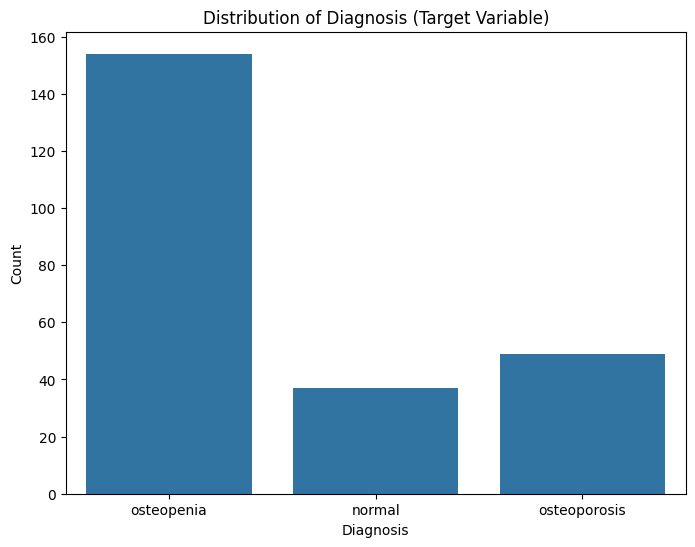

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='diagnosis', data=df1)
plt.title('Distribution of Diagnosis (Target Variable)')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

In [ ]:
import numpy as np

def clean_categorical_values(df, columns):
    for col in columns:
        if col in df.columns and df[col].dtype == 'object': # Only process object type columns
            df[col] = df[col].astype(str).str.lower().str.strip()
            # Custom replacements for known variations
            if col == 'obesity':
                df[col] = df[col].replace({'over weight': 'overweight'})
            elif col == 'daily_eating_habits':
                df[col] = df[col].replace({
                    'low protiens': 'low protein',
                    'low protien': 'low protein',
                    'low peotien': 'low protein',
                    'not fats, low protien': 'not fats, low protein',
                    'low protien, fats and no sour food': 'low protein, fats and no sour food',
                    'low protien & sugar': 'low protein & sugar',
                    'no fats, low protien': 'no fats, low protein'
                })
            elif col == 'history_of_fracture':
                df[col] = df[col].replace({
                    'l.leg': 'left leg', 'r.leg': 'right leg',
                    'l.knee': 'left knee', 'r.knee': 'right knee',
                    'l.foot': 'left foot', 'r.foot': 'right foot',
                    'r.wrist': 'right wrist', 'l.wrist': 'left wrist',
                    'r.arm': 'right arm', 'l.arm': 'left arm',
                    'r.shoulder': 'right shoulder', 'l.shoulder': 'left shoulder',
                    'r.ankle': 'right ankle', 'l.ankle': 'left ankle',
                    'r.elbow': 'right elbow', 'l.elbow': 'left elbow',
                    'vertebral ': 'vertebral',
                    'shoulder ': 'shoulder'
                })
            elif col == 'occupation':
                df[col] = df[col].replace({'h.wife': 'housewife', 'r.g.e': 'rge', 'g.e': 'ge', 'r.n t': 'rnt', 'bussinesman': 'businessman'})
            # Replace 'nan' string with actual NaN
            df[col] = df[col].replace({'nan': np.nan})
    return df

# Identify categorical object columns in df1 for cleaning
categorical_cols_to_clean = df1.select_dtypes(include='object').columns.tolist()
# Exclude 'diagnosis' itself as it will be mapped to numeric
categorical_cols_to_clean = [col for col in categorical_cols_to_clean if col != 'diagnosis']

df1 = clean_categorical_values(df1, categorical_cols_to_clean)

print("Unique values for 'obesity' after cleaning:", df1['obesity'].unique())

Unique values for 'obesity' after cleaning: ['normal weight' 'overweight' 'obesity' 'under weight']


In [ ]:
df1.columns

Index(['patient_id', 'joint_pain', 'gender', 'age', 'menopause_age',
       'height_meter', 'weight_kg', 'smoker', 'alcoholic', 'diabetic',
       'hypothyroidism', 'number_of_pregnancies', 'seizer_disorder',
       'estrogen_use', 'occupation', 'history_of_fracture', 'dialysis',
       'family_history_of_osteoporosis', 'maximum_walking_distance_km',
       'daily_eating_habits', 'medical_history', 'tscore_value',
       'zscore_value', 'bmi', 'site', 'obesity', 'diagnosis',
       'diagnosis_numeric'],
      dtype='object')

In [ ]:
summary_stats = df1.groupby('diagnosis')[['bmi', 'age']].agg(['mean', 'std', 'min', 'max', 'median'])
display(summary_stats)

bmi                                                   age  \
                   mean       std        min        max     median       mean   
diagnosis                                                                       
normal        26.230982  3.612122  20.158334  33.782262  26.346494  34.405405   
osteopenia    28.139044  4.124610  16.139658  42.754389  27.515925  51.116883   
osteoporosis  26.892824  3.808078  19.723866  34.720883  26.899430  63.387755   

                                             
                    std   min    max median  
diagnosis                                    
normal         6.643541  23.0   49.0   35.0  
osteopenia     8.934729  30.0   75.0   50.0  
osteoporosis  11.693688  17.0  107.0   65.0

### Target Var Distribution

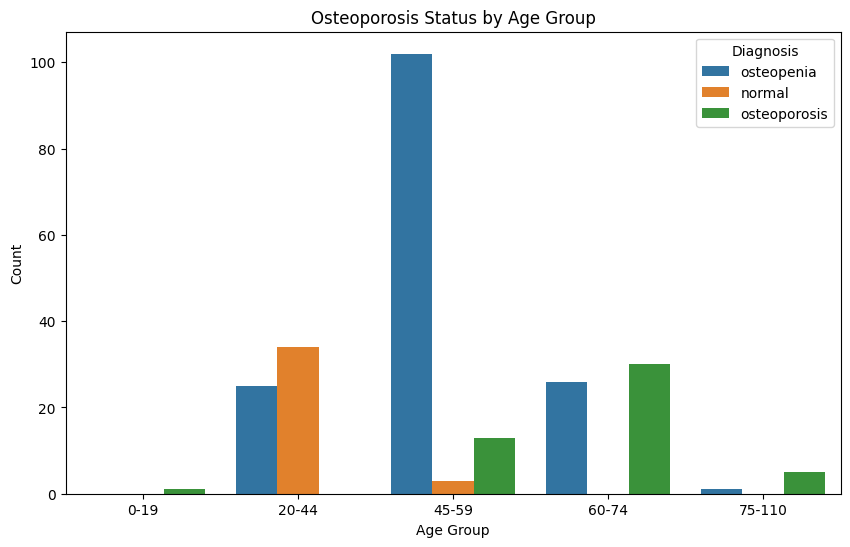

,age,age_group
0,65.0,60-74
1,54.0,45-59
2,49.0,45-59
3,57.0,45-59
4,40.0,20-44


In [ ]:
bins = [0, 19, 44, 59, 74, 110]
labels = ['0-19', '20-44', '45-59', '60-74', '75-110']
df1['age_group'] = pd.cut(df1['age'], bins=bins, labels=labels)

# Visualize age group distribution relative to the target
plt.figure(figsize=(10, 6))
sns.countplot(x='age_group', hue='diagnosis', data=df1)
plt.title('Osteoporosis Status by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='Diagnosis')
plt.show()

df1[['age', 'age_group']].head()

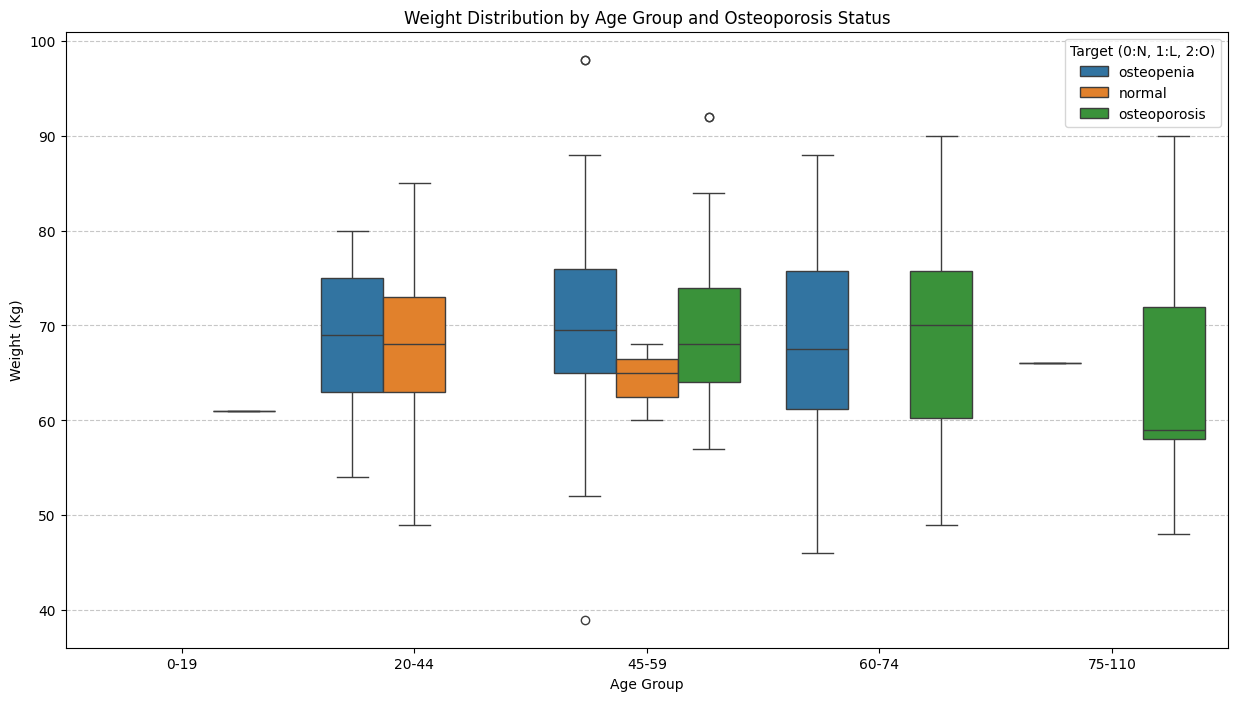

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(x='age_group', y='weight_kg', hue='diagnosis', data=df1)
plt.title('Weight Distribution by Age Group and Osteoporosis Status')
plt.xlabel('Age Group')
plt.ylabel('Weight (Kg)')
plt.legend(title='Target (0:N, 1:L, 2:O)', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Matrix Correlation

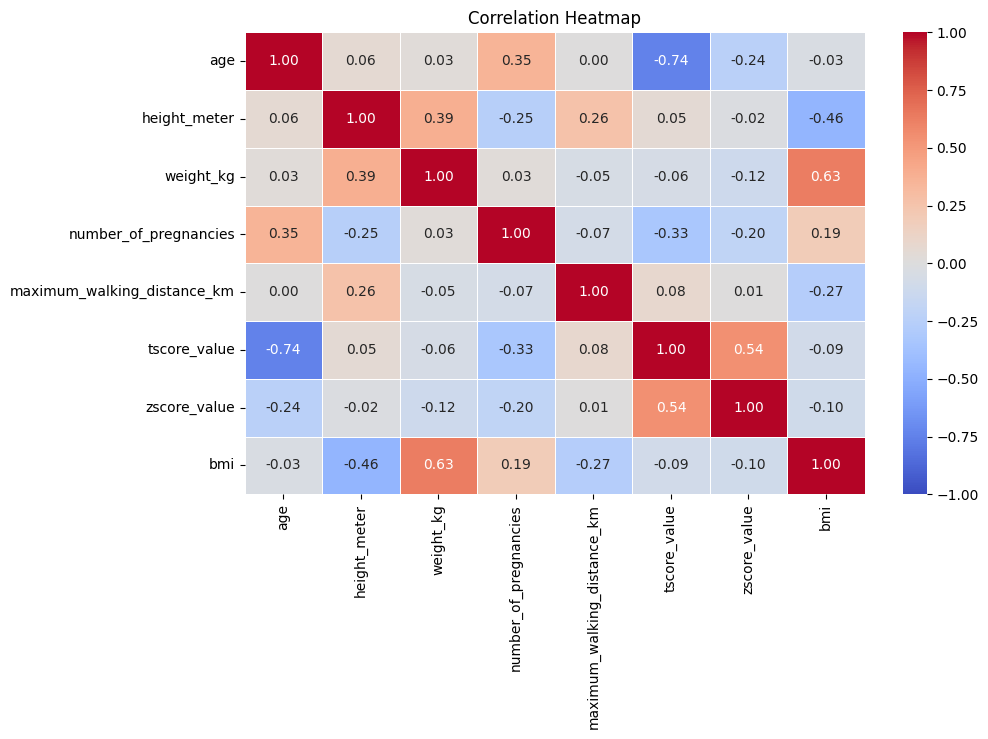

In [ ]:
# Create a correlation heatmap
numeric_cols_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 6))
sns.heatmap(numeric_cols_df.corr(), annot=True, cmap='coolwarm', center=0, vmin=-1, fmt='.2f', linewidth=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
score_osteopenia = df.groupby('diagnosis')['tscore_value'].mean()
score_osteopenia

,tscore_value
diagnosis,
normal,-0.647027
osteopenia,-1.851364
osteoporosis,-2.673878


In [ ]:
fig = px.scatter(df1, x='tscore_value', y='zscore_value', color='diagnosis',
                 title='T-Score vs Z-Score Distribution by Diagnosis',
                 labels={'tscore_value': 'T-Score Value', 'zscore_value': 'Z-Score Value'},
                 hover_data=['patient_id', 'age', 'gender'])
fig.update_layout(height=600, width=800)
fig.show()

### Feature Correlation

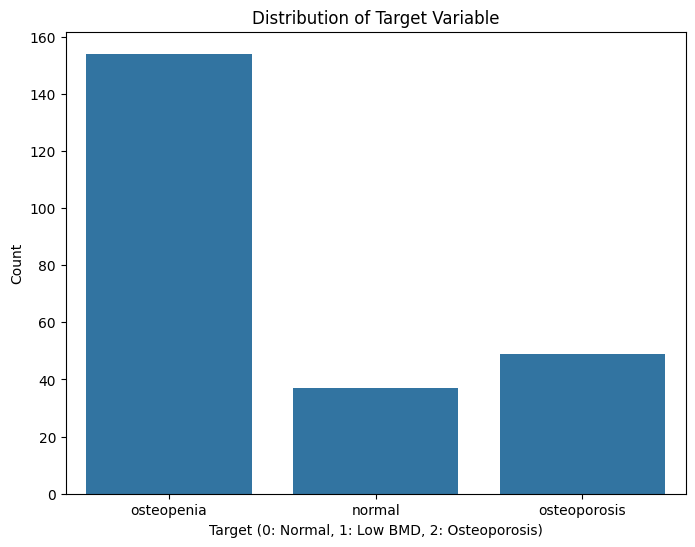

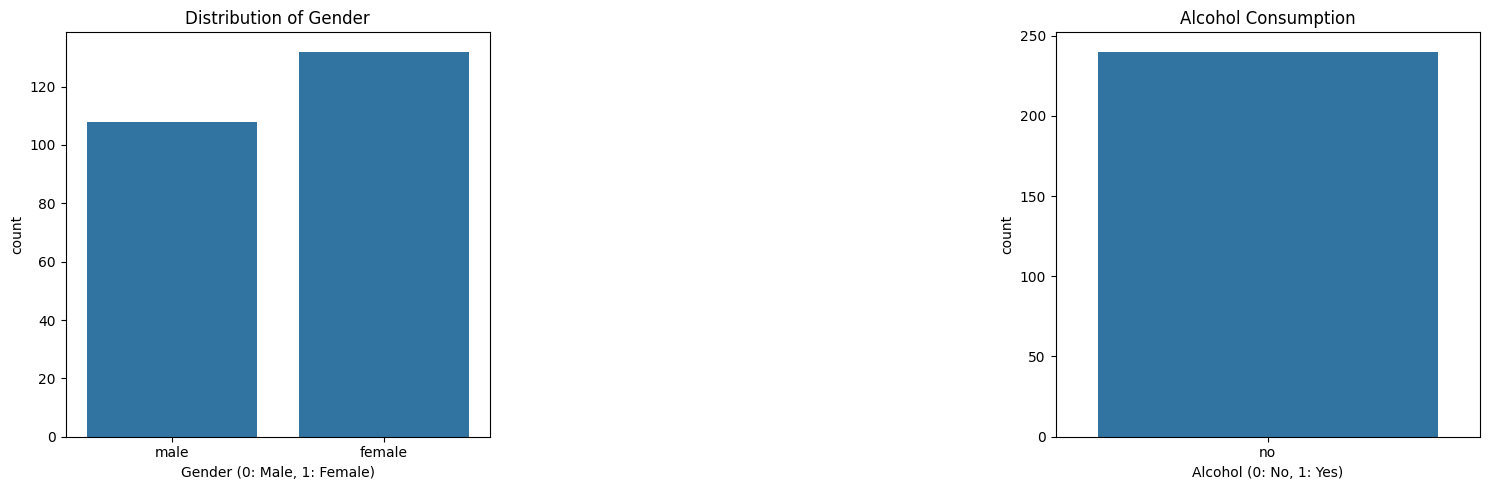

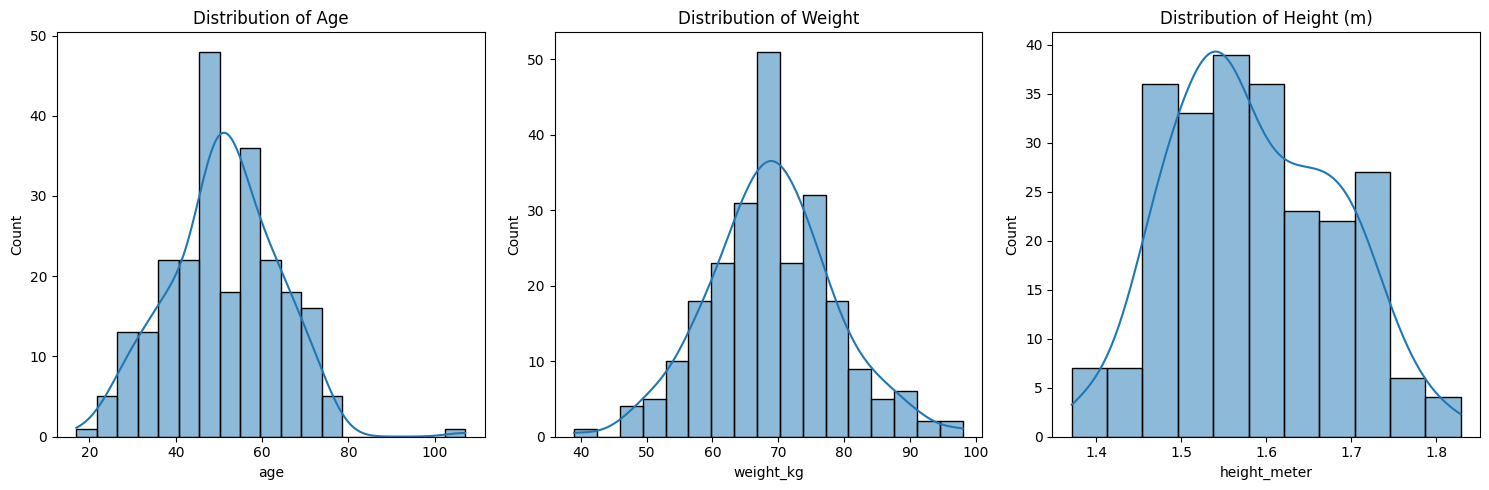

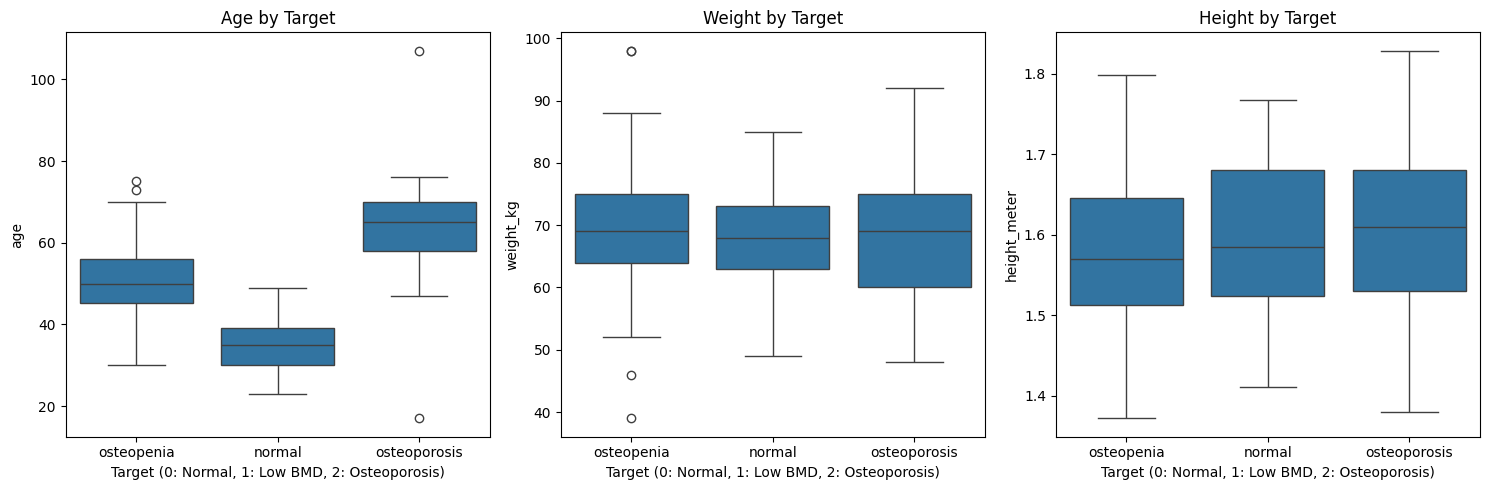

In [ ]:
# Visualizations for the target variable
plt.figure(figsize=(8, 6))
sns.countplot(x='diagnosis', data=df1)
plt.title('Distribution of Target Variable')
plt.xlabel('Target (0: Normal, 1: Low BMD, 2: Osteoporosis)')
plt.ylabel('Count')
plt.show()

# Visualizations for key categorical features
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.countplot(x='gender', data=df1)
plt.title('Distribution of Gender')
plt.xlabel('Gender (0: Male, 1: Female)')

plt.subplot(1, 3, 3)
sns.countplot(x='alcoholic', data=df1)
plt.title('Alcohol Consumption')
plt.xlabel('Alcohol (0: No, 1: Yes)')

plt.tight_layout()
plt.show()

# Visualizations for numerical features
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df1['age'], kde=True)
plt.title('Distribution of Age')

plt.subplot(1, 3, 2)
sns.histplot(df1['weight_kg'], kde=True)
plt.title('Distribution of Weight')

plt.subplot(1, 3, 3)
sns.histplot(df1['height_meter'], kde=True)
plt.title('Distribution of Height (m)')

plt.tight_layout()
plt.show()

# Box plots for numerical features vs target
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(x='diagnosis', y='age', data=df1)
plt.title('Age by Target')
plt.xlabel('Target (0: Normal, 1: Low BMD, 2: Osteoporosis)')

plt.subplot(1, 3, 2)
sns.boxplot(x='diagnosis', y='weight_kg', data=df1)
plt.title('Weight by Target')
plt.xlabel('Target (0: Normal, 1: Low BMD, 2: Osteoporosis)')

plt.subplot(1, 3, 3)
sns.boxplot(x='diagnosis', y='height_meter', data=df1)
plt.title('Height by Target')
plt.xlabel('Target (0: Normal, 1: Low BMD, 2: Osteoporosis)')

plt.tight_layout()
plt.show()

#### Statistical Analysis: Chi-Square Test for Categorical Features

We will use the Chi-Square ($\\chi^2$) test to assess if there is a statistically significant association between various categorical features and the 'diagnosis' (target) variable. A low p-value (typically < 0.05) indicates that the variables are not independent, suggesting a relationship between them.

In [ ]:
from scipy.stats import chi2_contingency
import pandas as pd

# Identify categorical columns (excluding 'age_group' and 'diagnosis' itself)
categorical_features = df1.select_dtypes(include='object').columns.tolist()
categorical_features = [col for col in categorical_features if col != 'diagnosis']

# Exclude columns that might have too many unique values or are complex for a simple chi-square
# For example, 'occupation', 'daily_eating_habits', 'medical_history' can have high cardinality
excluded_cols = ['occupation', 'daily_eating_habits', 'medical_history', 'menopause_age'] # Exclude 'menopause_age' as it's likely numerical even if type is object
categorical_features = [col for col in categorical_features if col not in excluded_cols]

chi2_results = []

print("Chi-Square Test Results for Categorical Features vs. Diagnosis:")
for feature in categorical_features:
    # Create a contingency table (cross-tabulation)
    # Drop NaNs for the specific feature and diagnosis for this test
    contingency_table = pd.crosstab(df1[feature], df1['diagnosis'])

    # Check if the contingency table is empty or has too few observations
    if contingency_table.empty or contingency_table.sum().sum() < 2:
        chi2_results.append({
            'Feature': feature,
            'Chi2 Statistic': 'N/A',
            'p-value': 'N/A',
            'Significant (alpha=0.05)': False,
            'Note': 'Insufficient data for test'
        })
        continue

    # Perform the Chi-square test
    chi2, p, dof, expected = chi2_contingency(contingency_table)

    alpha = 0.05 # Significance level

    chi2_results.append({
        'Feature': feature,
        'Chi2 Statistic': chi2,
        'p-value': p,
        'Significant (alpha=0.05)': p < alpha
    })

# Display the results in a DataFrame
chi2_df = pd.DataFrame(chi2_results)
display(chi2_df)

Chi-Square Test Results for Categorical Features vs. Diagnosis:


,Feature,Chi2 Statistic,p-value,Significant (alpha=0.05)
0,patient_id,480.000000,0.465673,False
1,joint_pain,1.238521,0.538342,False
2,gender,9.587466,0.008281,True
3,smoker,3.957965,0.138210,False
4,alcoholic,0.000000,1.000000,False
5,diabetic,6.822286,0.033003,True
6,hypothyroidism,9.023338,0.010980,True
7,seizer_disorder,4.621585,0.099183,False
8,estrogen_use,3.937814,0.139609,False
9,history_of_fracture,72.939888,0.752624,False


#### Correlation Analysis: Lifestyle Factors

Calculating the Pearson correlation between alcohol, smoking, and activity.

In [ ]:
# The 'activity' column is not found in df1. Using 'maximum_walking_distance_km' as a proxy.
# print(df1.activity.unique())
print(f"Available columns in df1: {df1.columns.tolist()}")

Available columns in df1: ['patient_id', 'joint_pain', 'gender', 'age', 'menopause_age', 'height_meter', 'weight_kg', 'smoker', 'alcoholic', 'diabetic', 'hypothyroidism', 'number_of_pregnancies', 'seizer_disorder', 'estrogen_use', 'occupation', 'history_of_fracture', 'dialysis', 'family_history_of_osteoporosis', 'maximum_walking_distance_km', 'daily_eating_habits', 'medical_history', 'tscore_value', 'zscore_value', 'bmi', 'site', 'obesity', 'diagnosis', 'diagnosis_numeric', 'age_group']


Value counts for 'alcoholic' column (after initial mapping, before fillna):


,count
alcoholic,
0,240


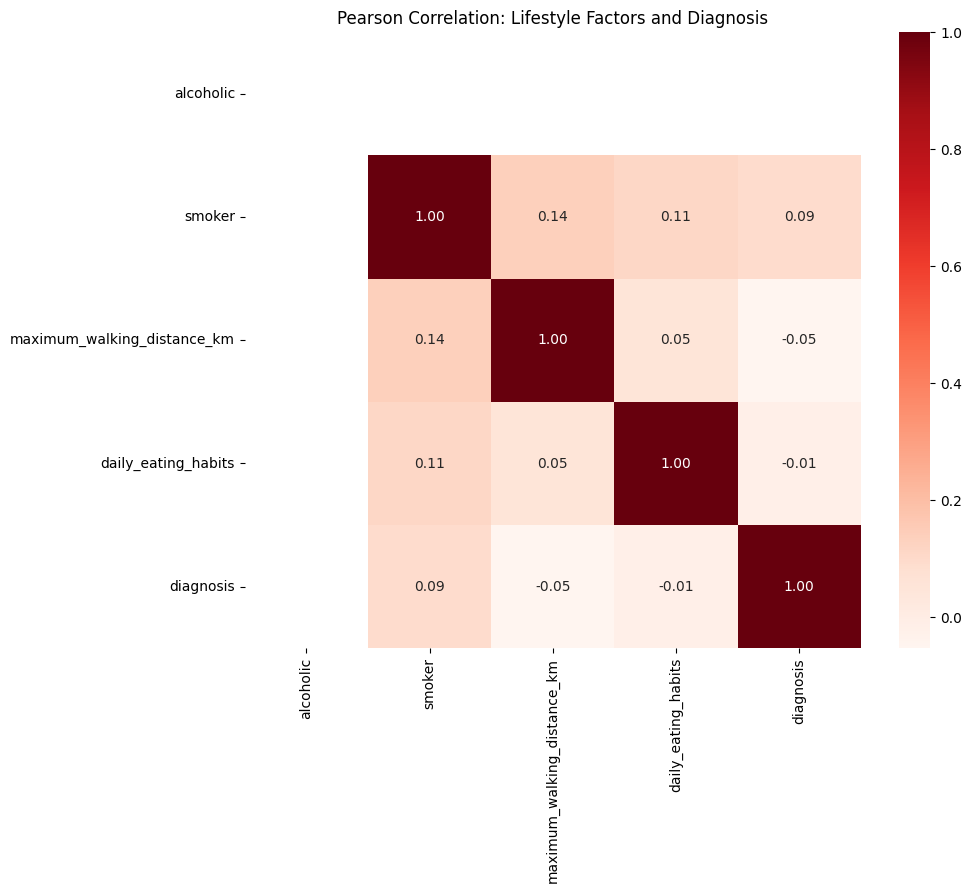

,alcoholic,smoker,maximum_walking_distance_km,daily_eating_habits,diagnosis
alcoholic,NaN,NaN,NaN,NaN,NaN
smoker,NaN,1.000000,0.138258,0.114195,0.091868
maximum_walking_distance_km,NaN,0.138258,1.000000,0.050194,-0.053128
daily_eating_habits,NaN,0.114195,0.050194,1.000000,-0.012144
diagnosis,NaN,0.091868,-0.053128,-0.012144,1.000000


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Map categorical lifestyle factors to numeric
lifestyle_map = {'no': 0, 'yes': 1}
target_map = {'normal': 0, 'osteopenia': 1, 'osteoporosis': 2}

# Prepare a temporary dataframe for correlation, using 'maximum_walking_distance_km' as proxy for 'activity'
df_corr = df1[['alcoholic', 'smoker', 'maximum_walking_distance_km', 'daily_eating_habits', 'diagnosis']].copy()

# Apply mappings to convert categorical columns to numeric in df_corr
df_corr['alcoholic'] = df_corr['alcoholic'].map(lifestyle_map)
df_corr['smoker'] = df_corr['smoker'].map(lifestyle_map)
df_corr['diagnosis'] = df_corr['diagnosis'].map(target_map)

# Handle 'daily_eating_habits' using LabelEncoder
le_daily_eating = LabelEncoder()
# Fill NaN values before encoding
df_corr['daily_eating_habits'] = df_corr['daily_eating_habits'].fillna('unknown')
df_corr['daily_eating_habits'] = le_daily_eating.fit_transform(df_corr['daily_eating_habits'])

# Check value counts for 'alcoholic' to understand why correlation might be NaN
print("Value counts for 'alcoholic' column (after initial mapping, before fillna):")
display(df_corr['alcoholic'].value_counts(dropna=False))

# Fill NaN values (e.g., from mapping or original data) with 0 for correlation purposes
df_corr['alcoholic'].fillna(0, inplace=True)

# Calculate correlation
correlation_matrix = df_corr.corr(method='pearson')

# Display the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='Reds', fmt='.2f', square=True)
plt.title('Pearson Correlation: Lifestyle Factors and Diagnosis')
plt.show()

display(correlation_matrix)

#### Correlation Analysis: Women's Medical Records

Calculating the Pearson correlation between specific women's health-related features and the target variable.

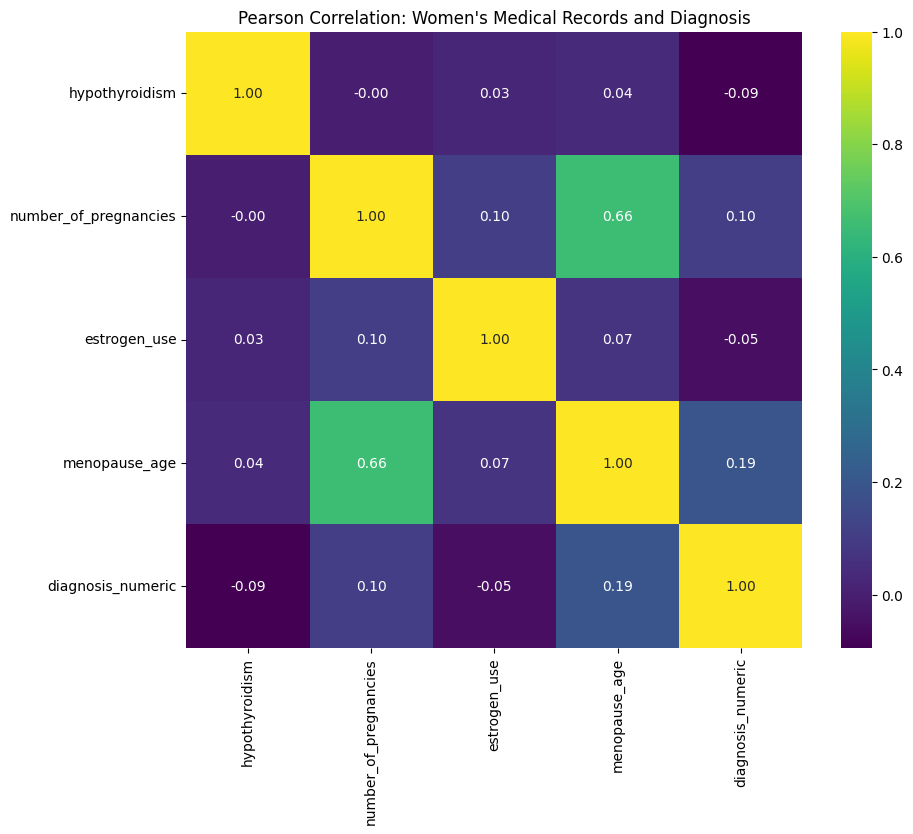

,hypothyroidism,number_of_pregnancies,estrogen_use,menopause_age,diagnosis_numeric
hypothyroidism,1.000000,-0.002914,0.025236,0.037064,-0.094146
number_of_pregnancies,-0.002914,1.000000,0.103080,0.655946,0.102737
estrogen_use,0.025236,0.103080,1.000000,0.068679,-0.051772
menopause_age,0.037064,0.655946,0.068679,1.000000,0.193745
diagnosis_numeric,-0.094146,0.102737,-0.051772,0.193745,1.000000


In [ ]:
# Define the columns for women's health correlation
women_health_cols = ['hypothyroidism', 'number_of_pregnancies', 'estrogen_use', 'menopause_age', 'diagnosis_numeric']

# Create a temporary dataframe for correlation
df_women_health_corr = df1[women_health_cols].copy()

# Map 'yes'/'no' categorical features to numeric (1/0)
binary_map = {'no': 0, 'yes': 1}
df_women_health_corr['hypothyroidism'] = df_women_health_corr['hypothyroidism'].map(binary_map)
df_women_health_corr['estrogen_use'] = df_women_health_corr['estrogen_use'].map(binary_map)

# Convert 'menopause_age' to numeric, coercing errors to NaN, then fill NaNs with 0
df_women_health_corr['menopause_age'] = pd.to_numeric(df_women_health_corr['menopause_age'], errors='coerce')
df_women_health_corr['menopause_age'].fillna(0, inplace=True)

# Fill NaN values in 'number_of_pregnancies' with 0 for correlation purposes
df_women_health_corr['number_of_pregnancies'].fillna(0, inplace=True)

# Calculate correlation
women_health_correlation_matrix = df_women_health_corr.corr(method='pearson')

# Display the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(women_health_correlation_matrix, annot=True, cmap='viridis', fmt='.2f', square=True)
plt.title('Pearson Correlation: Women\'s Medical Records and Diagnosis')
plt.show()

display(women_health_correlation_matrix)

#### Correlation Analysis: General Health Medical Records

Calculating the Pearson correlation between various general health records and the target variable.

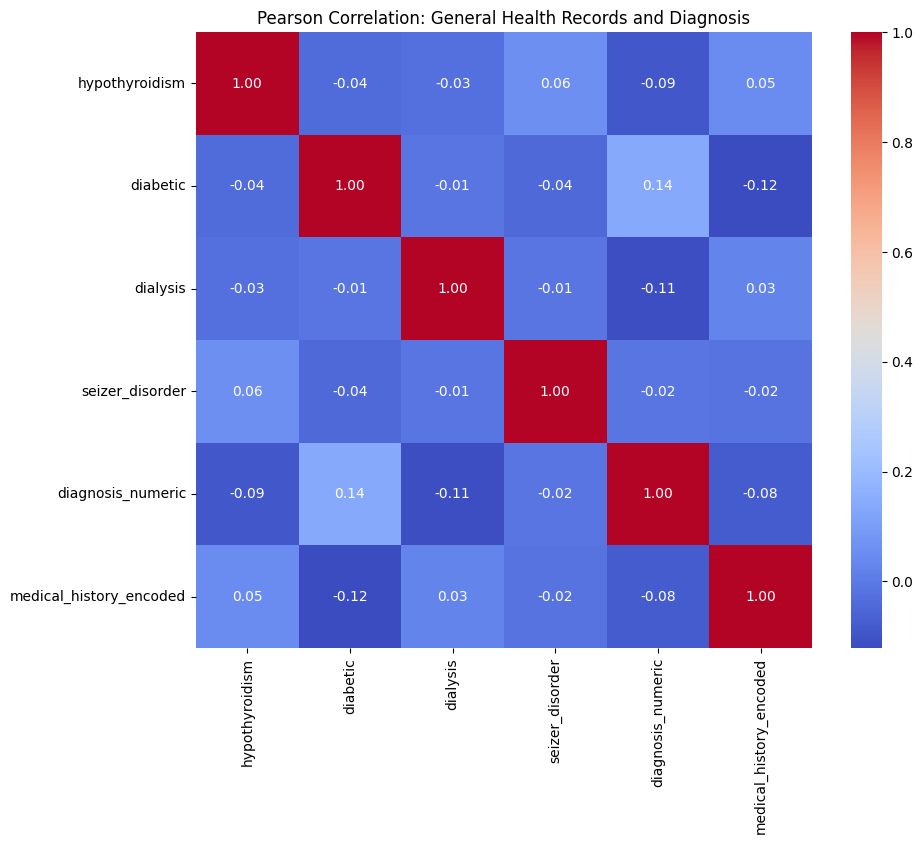

,hypothyroidism,diabetic,dialysis,seizer_disorder,diagnosis_numeric,medical_history_encoded
hypothyroidism,1.000000,-0.038378,-0.026279,0.057690,-0.094146,0.047176
diabetic,-0.038378,1.000000,-0.014840,-0.042601,0.141017,-0.121174
dialysis,-0.026279,-0.014840,1.000000,-0.012012,-0.113859,0.026360
seizer_disorder,0.057690,-0.042601,-0.012012,1.000000,-0.015565,-0.017494
diagnosis_numeric,-0.094146,0.141017,-0.113859,-0.015565,1.000000,-0.081181
medical_history_encoded,0.047176,-0.121174,0.026360,-0.017494,-0.081181,1.000000


In [ ]:
# Define the columns for general health records correlation
general_health_cols = ['hypothyroidism', 'diabetic', 'dialysis', 'medical_history', 'seizer_disorder', 'diagnosis_numeric']

# Create a temporary dataframe for correlation
df_general_health_corr = df1[general_health_cols].copy()

# Map 'yes'/'no' categorical features to numeric (1/0)
binary_map = {'no': 0, 'yes': 1}
df_general_health_corr['hypothyroidism'] = df_general_health_corr['hypothyroidism'].replace(binary_map)
df_general_health_corr['diabetic'] = df_general_health_corr['diabetic'].replace(binary_map)
df_general_health_corr['dialysis'] = df_general_health_corr['dialysis'].replace(binary_map)
df_general_health_corr['seizer_disorder'] = df_general_health_corr['seizer_disorder'].replace(binary_map)

# For 'medical_history', use Label Encoding as it's categorical with multiple unique values
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

if 'medical_history' in df_general_health_corr.columns and df_general_health_corr['medical_history'].dtype == 'object':
    df_general_health_corr['medical_history'].fillna('unknown', inplace=True)
    df_general_health_corr['medical_history_encoded'] = le.fit_transform(df_general_health_corr['medical_history'])

# Drop original 'medical_history' object column if it was encoded
if 'medical_history' in df_general_health_corr.columns:
    df_general_health_corr = df_general_health_corr.drop(columns=['medical_history'])

# Fill any remaining NaNs (e.g., from original data in binary columns) with 0 for correlation purposes
df_general_health_corr.fillna(0, inplace=True)

# Calculate correlation
general_health_correlation_matrix = df_general_health_corr.corr(method='pearson')

# Display the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(general_health_correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Pearson Correlation: General Health Records and Diagnosis')
plt.show()

display(general_health_correlation_matrix)

Remove all General Health Check and lifestyle factors as no contribute in diagnosis of osteoporosis

# Data Preparation

## Handling Missing Value & Duplicate

In [ ]:
clean_df = df1.copy()
clean_df.isna().sum()

,0
patient_id,0
joint_pain,0
gender,0
age,0
menopause_age,157
height_meter,0
weight_kg,0
smoker,0
alcoholic,0
diabetic,0


In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   patient_id                      240 non-null    object  
 1   joint_pain                      240 non-null    object  
 2   gender                          240 non-null    object  
 3   age                             240 non-null    float64 
 4   menopause_age                   83 non-null     object  
 5   height_meter                    240 non-null    float64 
 6   weight_kg                       240 non-null    float64 
 7   smoker                          240 non-null    object  
 8   alcoholic                       240 non-null    object  
 9   diabetic                        240 non-null    object  
 10  hypothyroidism                  240 non-null    object  
 11  number_of_pregnancies           124 non-null    float64 
 12  seizer_disorder       

In [ ]:
clean_df[clean_df.isna().any(axis=1)]

,patient_id,joint_pain,gender,age,menopause_age,height_meter,weight_kg,smoker,alcoholic,diabetic,...,daily_eating_habits,medical_history,tscore_value,zscore_value,bmi,site,obesity,diagnosis,diagnosis_numeric,age_group
0,op1,yes,male,65.0,NaN,1.64592,65.0,yes,no,no,...,normal,normal,-1.98,0.73,23.993627,knee,normal weight,osteopenia,1,60-74
4,op5,yes,female,40.0,NaN,1.49352,54.0,no,no,no,...,normal,depression,-1.81,-1.05,24.208711,knee,normal weight,osteopenia,1,20-44
5,op6,yes,male,53.0,NaN,1.61544,64.0,no,no,no,...,low protein,"r.arthritis, appendix",-1.08,-0.46,24.524395,knee,normal weight,osteopenia,1,45-59
6,op7,yes,male,60.0,NaN,1.52400,64.0,yes,no,no,...,normal,no,-1.73,-0.92,27.555611,knee,overweight,osteopenia,1,60-74
7,op8,yes,female,46.0,NaN,1.43256,63.0,no,no,no,...,normal,no,-1.87,-1.59,30.698341,knee,obesity,osteopenia,1,45-59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,op151,yes,male,54.0,NaN,1.69000,68.0,no,no,no,...,normal,no,-2.02,-2.45,23.808690,knee,normal weight,osteopenia,1,45-59
235,op152,yes,female,56.0,NaN,1.54000,80.0,no,no,no,...,normal,"scizerian, b.p",-1.97,-1.34,33.732501,knee,obesity,osteopenia,1,45-59
236,os49,yes,male,55.0,NaN,1.53000,63.0,no,no,no,...,normal,heart,-2.99,-2.42,26.912726,knee,overweight,osteoporosis,2,45-59
237,op153,yes,male,49.0,NaN,1.67000,88.0,no,no,no,...,normal,"g.b rem, fatty liver",-1.72,-1.21,31.553659,knee,obesity,osteopenia,1,45-59


In [ ]:
print(f'Amount of Missing Values before Drop Deviation Columns: {clean_df.isna().sum()}')

Amount of Missing Values before Drop Deviation Columns: patient_id                          0
joint_pain                          0
gender                              0
age                                 0
menopause_age                     157
height_meter                        0
weight_kg                           0
smoker                              0
alcoholic                           0
diabetic                            0
hypothyroidism                      0
number_of_pregnancies             116
seizer_disorder                     0
estrogen_use                        0
occupation                          4
history_of_fracture                 0
dialysis                            0
family_history_of_osteoporosis      0
maximum_walking_distance_km         1
daily_eating_habits                 2
medical_history                     0
tscore_value                        0
zscore_value                        0
bmi                                 0
site                            

In [ ]:
clean_df['menopause_age'] = clean_df.menopause_age.fillna(0)
clean_df['number_of_pregnancies'] = clean_df.number_of_pregnancies.fillna(0)
clean_df = clean_df.fillna(method='bfill')
print(f'Amount of Missing Values after Drop Deviation Columns: {clean_df.head().isna().sum()}')

Amount of Missing Values after Drop Deviation Columns: patient_id                        0
joint_pain                        0
gender                            0
age                               0
menopause_age                     0
height_meter                      0
weight_kg                         0
smoker                            0
alcoholic                         0
diabetic                          0
hypothyroidism                    0
number_of_pregnancies             0
seizer_disorder                   0
estrogen_use                      0
occupation                        0
history_of_fracture               0
dialysis                          0
family_history_of_osteoporosis    0
maximum_walking_distance_km       0
daily_eating_habits               0
medical_history                   0
tscore_value                      0
zscore_value                      0
bmi                               0
site                              0
obesity                           0
diagnosis

In [ ]:
clean_df[clean_df.isna().any(axis=1)]

,patient_id,joint_pain,gender,age,menopause_age,height_meter,weight_kg,smoker,alcoholic,diabetic,...,daily_eating_habits,medical_history,tscore_value,zscore_value,bmi,site,obesity,diagnosis,diagnosis_numeric,age_group


In [ ]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   patient_id                      240 non-null    object  
 1   joint_pain                      240 non-null    object  
 2   gender                          240 non-null    object  
 3   age                             240 non-null    float64 
 4   menopause_age                   240 non-null    object  
 5   height_meter                    240 non-null    float64 
 6   weight_kg                       240 non-null    float64 
 7   smoker                          240 non-null    object  
 8   alcoholic                       240 non-null    object  
 9   diabetic                        240 non-null    object  
 10  hypothyroidism                  240 non-null    object  
 11  number_of_pregnancies           240 non-null    float64 
 12  seizer_disorder       

In [ ]:
clean_df.duplicated().sum()

np.int64(0)

In [ ]:
clean_df[clean_df.duplicated()]

,patient_id,joint_pain,gender,age,menopause_age,height_meter,weight_kg,smoker,alcoholic,diabetic,...,daily_eating_habits,medical_history,tscore_value,zscore_value,bmi,site,obesity,diagnosis,diagnosis_numeric,age_group


Tidak ada Data Duplikat dan Kosong : **Tidak perlu Pengolahan *Drop* atau Imputasi .**

## Drop Age < 60, Hanya Lansia

In [ ]:
drop_df = clean_df[clean_df['age'] >= 59]
drop_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65 entries, 0 to 231
Data columns (total 29 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   patient_id                      65 non-null     object  
 1   joint_pain                      65 non-null     object  
 2   gender                          65 non-null     object  
 3   age                             65 non-null     float64 
 4   menopause_age                   65 non-null     object  
 5   height_meter                    65 non-null     float64 
 6   weight_kg                       65 non-null     float64 
 7   smoker                          65 non-null     object  
 8   alcoholic                       65 non-null     object  
 9   diabetic                        65 non-null     object  
 10  hypothyroidism                  65 non-null     object  
 11  number_of_pregnancies           65 non-null     float64 
 12  seizer_disorder             

In [ ]:
drop_df.head()

,patient_id,joint_pain,gender,age,menopause_age,height_meter,weight_kg,smoker,alcoholic,diabetic,...,daily_eating_habits,medical_history,tscore_value,zscore_value,bmi,site,obesity,diagnosis,diagnosis_numeric,age_group
0,op1,yes,male,65.0,0,1.64592,65.0,yes,no,no,...,normal,normal,-1.98,0.73,23.993627,knee,normal weight,osteopenia,1,60-74
6,op7,yes,male,60.0,0,1.52400,64.0,yes,no,no,...,normal,no,-1.73,-0.92,27.555611,knee,overweight,osteopenia,1,60-74
11,op12,yes,male,60.0,0,1.52400,56.0,no,no,no,...,normal,no,-1.42,-1.08,24.111159,knee,normal weight,osteopenia,1,60-74
18,op16,yes,male,64.0,0,1.58496,70.0,yes,no,no,...,normal,b.p,-1.81,-0.83,27.865153,knee,overweight,osteopenia,1,60-74
19,op17,yes,male,65.0,0,1.55448,61.0,no,no,no,...,normal,no,-1.13,-0.91,25.244081,knee,overweight,osteopenia,1,60-74


In [ ]:
drop_df.diagnosis.value_counts()

,count
diagnosis,
osteoporosis,36
osteopenia,29


Menerapkan Labelisasi pada feature categorical sebagai representasi numerik sebagai input model nantinya.

## Dropping Un-useful features

In [ ]:
useless_cols = ['smoker', 'alcoholic',
       'diabetic', 'hypothyroidism', 'seizer_disorder', 'estrogen_use',
       'occupation', 'dialysis','daily_eating_habits',
       'medical_history']

In [ ]:
for i in useless_cols:
    drop_df.drop(i, axis=1, inplace=True)
cols = drop_df.columns
cols

Index(['patient_id', 'joint_pain', 'gender', 'age', 'menopause_age',
       'height_meter', 'weight_kg', 'number_of_pregnancies',
       'history_of_fracture', 'family_history_of_osteoporosis',
       'maximum_walking_distance_km', 'tscore_value', 'zscore_value', 'bmi',
       'site', 'obesity', 'diagnosis', 'diagnosis_numeric', 'age_group'],
      dtype='object')

## One-Hot Encoding for Categorical Features

In [ ]:
df_labeled = drop_df.copy()
categorical_cols = df_labeled.select_dtypes(include='object').columns
categorical_cols

Index(['patient_id', 'joint_pain', 'gender', 'menopause_age',
       'history_of_fracture', 'family_history_of_osteoporosis', 'site',
       'obesity', 'diagnosis'],
      dtype='object')

In [ ]:
for i in categorical_cols:
    print(f"Unique values for {i}: {df_labeled[i].unique()}")

Unique values for patient_id: ['op1' 'op7' 'op12' 'op16' 'op17' 'os1' 'op20' 'op21' 'op23' 'op24' 'os2'
 'op26' 'op27' 'os3' 'os5' 'os6' 'op34' 'op36' 'op38' 'os7' 'op43' 'op50'
 'op51' 'op53' 'os10' 'op62' 'op64' 'op67' 'op73' 'op78' 'os11' 'os12'
 'os13' 'os14' 'os15' 'os16' 'os17' 'os18' 'os20' 'os21' 'op94' 'os22'
 'os23' 'os25' 'os27' 'os30' 'os32' 'os33' 'os34' 'os35' 'os36' 'os37'
 'os38' 'op122' 'op123' 'os39' 'os40' 'os42' 'os43' 'os44' 'os46' 'op144'
 'os48' 'op147' 'op148']
Unique values for joint_pain: ['yes']
Unique values for gender: ['male' 'female']
Unique values for menopause_age: [0 '50' '48' '47' '57' '45']
Unique values for history_of_fracture: ['no' 'right knee' 'vertebral' 'collar bone' 'left foot' 'right arm'
 'hip & head fracture' 'foot fracture' 'hip fracture' 'knee replaced'
 'arm fracture' 'yes' 'vertebral fracture' 'left leg' 'right ankle'
 'neck fracture' 'left knee' 'both legs' 'right leg']
Unique values for family_history_of_osteoporosis: ['no' 'yes']
Uni

In [ ]:
df_encoded = df_labeled.copy()

# Convert 'menopause_age' to numeric, coercing errors, and fill NaNs with 0
# (Assuming 0 or median is a reasonable imputation for menopausal age if not specified)
df_encoded['menopause_age'] = pd.to_numeric(df_encoded['menopause_age'], errors='coerce')
df_encoded['menopause_age'].fillna(0, inplace=True)

# Also fill NaNs for 'number_of_pregnancies' if not already done, as it's numerical
df_encoded['number_of_pregnancies'].fillna(0, inplace=True)

# Define columns to be one-hot encoded
# Exclude 'diagnosis' as 'diagnosis_numeric' is already available and will be used as the target
categorical_cols_for_ohe = [
    'joint_pain', 'gender', 'history_of_fracture',
    'family_history_of_osteoporosis', 'site', 'obesity'
]

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols_for_ohe, drop_first=True)

# Drop the original 'diagnosis' column since we have 'diagnosis_numeric'
df_encoded.drop(columns=['diagnosis'], inplace=True, errors='ignore')

# Drop 'patient_id' column as it is just an identifier and not a feature for the model
df_encoded.drop(columns=['patient_id'], inplace=True, errors='ignore')

print(f"Shape of DataFrame after One-Hot Encoding: {df_encoded.shape}")
display(df_encoded.head())

Shape of DataFrame after One-Hot Encoding: (65, 33)


,age,menopause_age,height_meter,weight_kg,number_of_pregnancies,maximum_walking_distance_km,tscore_value,zscore_value,bmi,diagnosis_numeric,...,history_of_fracture_right ankle,history_of_fracture_right arm,history_of_fracture_right knee,history_of_fracture_right leg,history_of_fracture_vertebral,history_of_fracture_vertebral fracture,history_of_fracture_yes,family_history_of_osteoporosis_yes,obesity_obesity,obesity_overweight
0,65.0,0,1.64592,65.0,0.0,0.2,-1.98,0.73,23.993627,1,...,False,False,False,False,False,False,False,False,False,False
6,60.0,0,1.52400,64.0,0.0,1.0,-1.73,-0.92,27.555611,1,...,False,False,True,False,False,False,False,False,False,True
11,60.0,0,1.52400,56.0,0.0,4.0,-1.42,-1.08,24.111159,1,...,False,False,False,False,False,False,False,False,False,False
18,64.0,0,1.58496,70.0,0.0,4.0,-1.81,-0.83,27.865153,1,...,False,False,False,False,False,False,False,False,False,True
19,65.0,0,1.55448,61.0,0.0,3.0,-1.13,-0.91,25.244081,1,...,False,False,False,False,False,False,False,True,False,True


The DataFrame `df_encoded` now contains the original numerical columns, the `menopause_age` and `number_of_pregnancies` (imputed), and the one-hot encoded versions of the selected categorical features. The original `diagnosis` column has been removed, retaining `diagnosis_numeric` as the target variable.

In [ ]:
df_encoded.head()

,age,menopause_age,height_meter,weight_kg,number_of_pregnancies,maximum_walking_distance_km,tscore_value,zscore_value,bmi,diagnosis_numeric,...,history_of_fracture_right ankle,history_of_fracture_right arm,history_of_fracture_right knee,history_of_fracture_right leg,history_of_fracture_vertebral,history_of_fracture_vertebral fracture,history_of_fracture_yes,family_history_of_osteoporosis_yes,obesity_obesity,obesity_overweight
0,65.0,0,1.64592,65.0,0.0,0.2,-1.98,0.73,23.993627,1,...,False,False,False,False,False,False,False,False,False,False
6,60.0,0,1.52400,64.0,0.0,1.0,-1.73,-0.92,27.555611,1,...,False,False,True,False,False,False,False,False,False,True
11,60.0,0,1.52400,56.0,0.0,4.0,-1.42,-1.08,24.111159,1,...,False,False,False,False,False,False,False,False,False,False
18,64.0,0,1.58496,70.0,0.0,4.0,-1.81,-0.83,27.865153,1,...,False,False,False,False,False,False,False,False,False,True
19,65.0,0,1.55448,61.0,0.0,3.0,-1.13,-0.91,25.244081,1,...,False,False,False,False,False,False,False,True,False,True


In [ ]:
clean_df = df_encoded.copy()

## Standardization

In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale (excluding the target variable)
numerical_cols_to_scale = clean_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
if 'diagnosis_numeric' in numerical_cols_to_scale:
    numerical_cols_to_scale.remove('diagnosis_numeric')

scaler = StandardScaler()
clean_df[numerical_cols_to_scale] = scaler.fit_transform(clean_df[numerical_cols_to_scale])

print(f"Remaining rows after cleaning: {len(clean_df)}")
clean_df.head()

Remaining rows after cleaning: 65


,age,menopause_age,height_meter,weight_kg,number_of_pregnancies,maximum_walking_distance_km,tscore_value,zscore_value,bmi,diagnosis_numeric,...,history_of_fracture_right ankle,history_of_fracture_right arm,history_of_fracture_right knee,history_of_fracture_right leg,history_of_fracture_vertebral,history_of_fracture_vertebral fracture,history_of_fracture_yes,family_history_of_osteoporosis_yes,obesity_obesity,obesity_overweight
0,-0.174672,-0.546774,0.405588,-0.253936,-0.510897,-0.844509,0.928635,3.326530,-0.580217,1,...,False,False,False,False,False,False,False,False,False,False
6,-0.893259,-0.546774,-0.875706,-0.349345,-0.510897,-0.465936,1.526034,0.706686,0.338772,1,...,False,False,True,False,False,False,False,False,False,True
11,-0.893259,-0.546774,-0.875706,-1.112619,-0.510897,0.953713,2.266810,0.452641,-0.549894,1,...,False,False,False,False,False,False,False,False,False,False
18,-0.318389,-0.546774,-0.235059,0.223111,-0.510897,0.953713,1.334867,0.849587,0.418633,1,...,False,False,False,False,False,False,False,False,False,True
19,-0.174672,-0.546774,-0.555382,-0.635573,-0.510897,0.480496,2.959794,0.722564,-0.257601,1,...,False,False,False,False,False,False,False,True,False,True


Proses untuk mengubah data agar memiliki format dan struktur yang konsisten sehingga dapat diproses dan dianalisis dengan lebih mudah dan efisien.

## IQR

**IQR** adalah konsep statistik yang terkait dengan distribusi data, dan penggunaannya untuk outlier adalah salah satu aplikasi utamanya. IQR mewakili rentang nilai yang mencakup 50% bagian tengah data Anda ketika diurutkan. Ini adalah ukuran penyebaran data yang "tahan" terhadap nilai-nilai ekstrem.

- Kuartil Pertama (Q1): Nilai di bawahnya terletak 25% data.
- Kuartil Ketiga (Q3): Nilai di bawahnya terletak 75% data (atau 25% data terletak di atasnya).
- IQR: Adalah perbedaan antara Kuartil Ketiga (Q3) dan Kuartil Pertama (Q1). IQR = Q3 - Q1

In [ ]:
cols = clean_df.columns

In [ ]:
out_iqr = clean_df.copy()
# Cek Outlier dengan IQR Outlier
def outlier_iqr(data):
    outliers = []
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    for i in data:
        if i < lower_bound or i > upper_bound:
            outliers.append(i)
    return outliers

print('Before Drop Outliers')
data_outlier = {}
# Iterate over numeric columns currently present in out_iqr
for col in out_iqr.select_dtypes(include=[np.number]).columns:
    data_outlier[col] = outlier_iqr(out_iqr[col])
    print('Outlier (' + col + '):', len(data_outlier[col]), 'outliers')

Before Drop Outliers
Outlier (age): 1 outliers
Outlier (menopause_age): 15 outliers
Outlier (height_meter): 0 outliers
Outlier (weight_kg): 0 outliers
Outlier (number_of_pregnancies): 15 outliers
Outlier (maximum_walking_distance_km): 4 outliers
Outlier (tscore_value): 1 outliers
Outlier (zscore_value): 1 outliers
Outlier (bmi): 1 outliers
Outlier (diagnosis_numeric): 0 outliers


### Visualizing Outliers Before Treatment

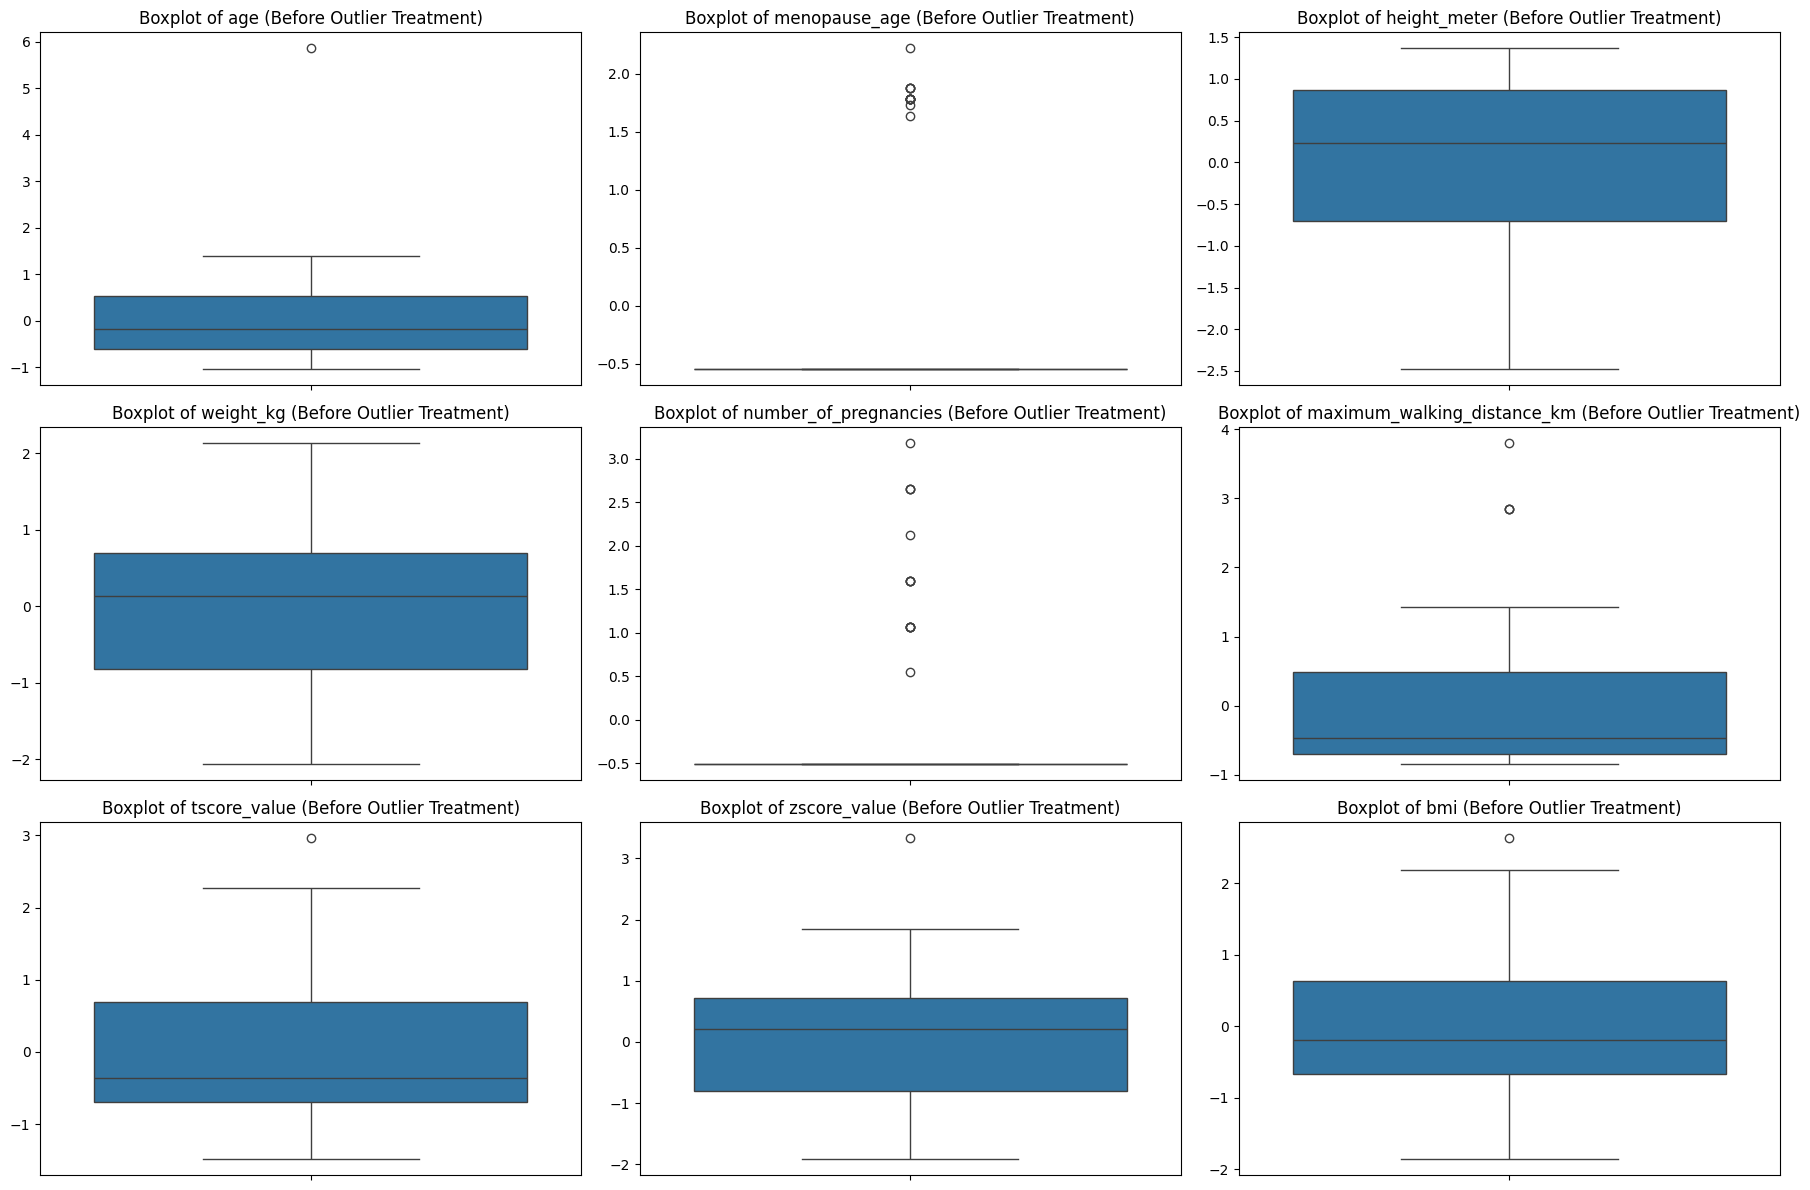

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Identify numerical columns from out_iqr for outlier visualization
numerical_cols_for_outlier_check = out_iqr.select_dtypes(include=[np.number]).columns.tolist()

# Exclude 'diagnosis_numeric' as it's the target variable and not a continuous feature for outlier detection in the same sense
if 'diagnosis_numeric' in numerical_cols_for_outlier_check:
    numerical_cols_for_outlier_check.remove('diagnosis_numeric')

plt.figure(figsize=(18, 12))
num_plots = len(numerical_cols_for_outlier_check)
# Calculate number of rows for subplots, assuming 3 columns per row
num_rows = (num_plots + 2) // 3

for i, col in enumerate(numerical_cols_for_outlier_check):
    plt.subplot(num_rows, 3, i + 1)
    sns.boxplot(y=out_iqr[col]) # Changed from drop_df to out_iqr
    plt.title(f'Boxplot of {col} (Before Outlier Treatment)')
    plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
#Drop Outliers
def dropOutlier(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3-Q1

    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    data = np.where(data > upper_bound, upper_bound, data)
    data = np.where(data < lower_bound, lower_bound, data)
    return data

# Get numeric columns from the current out_iqr
current_numeric_cols = out_iqr.select_dtypes(include=[np.number]).columns

# Exclude 'diagnosis_numeric' from outlier treatment as it is a target variable representing classes
numeric_cols_for_outlier_treatment = [col for col in current_numeric_cols if col != 'diagnosis_numeric']

for col in numeric_cols_for_outlier_treatment:
    out_iqr[col] = dropOutlier(out_iqr[col])

print('After Drop Outliers')
data_outlier = {}
# Re-run outlier check only for columns that were treated
for col in numeric_cols_for_outlier_treatment:
    data_outlier[col] = outlier_iqr(out_iqr[col])
    print('Outlier (' + col + '):', len(data_outlier[col]), 'outliers')
# For diagnosis_numeric, just confirm it wasn't affected (should have its original values)
if 'diagnosis_numeric' in current_numeric_cols:
    data_outlier['diagnosis_numeric'] = outlier_iqr(out_iqr['diagnosis_numeric'])
    print('Outlier (diagnosis_numeric):', len(data_outlier['diagnosis_numeric']), 'outliers')

After Drop Outliers
Outlier (age): 0 outliers
Outlier (menopause_age): 0 outliers
Outlier (height_meter): 0 outliers
Outlier (weight_kg): 0 outliers
Outlier (number_of_pregnancies): 0 outliers
Outlier (maximum_walking_distance_km): 0 outliers
Outlier (tscore_value): 0 outliers
Outlier (zscore_value): 0 outliers
Outlier (bmi): 0 outliers
Outlier (diagnosis_numeric): 0 outliers


## Train-Test Split

Langkah fundamental dalam alur kerja Machine Learning. Tujuan utamanya adalah untuk mengevaluasi kinerja model Anda pada data yang belum pernah dilihatnya selama pelatihan.



In [ ]:
cols

Index(['age', 'menopause_age', 'height_meter', 'weight_kg',
       'number_of_pregnancies', 'maximum_walking_distance_km', 'tscore_value',
       'zscore_value', 'bmi', 'diagnosis_numeric', 'age_group', 'gender_male',
       'history_of_fracture_both legs', 'history_of_fracture_collar bone',
       'history_of_fracture_foot fracture',
       'history_of_fracture_hip & head fracture',
       'history_of_fracture_hip fracture', 'history_of_fracture_knee replaced',
       'history_of_fracture_left foot', 'history_of_fracture_left knee',
       'history_of_fracture_left leg', 'history_of_fracture_neck fracture',
       'history_of_fracture_no', 'history_of_fracture_right ankle',
       'history_of_fracture_right arm', 'history_of_fracture_right knee',
       'history_of_fracture_right leg', 'history_of_fracture_vertebral',
       'history_of_fracture_vertebral fracture', 'history_of_fracture_yes',
       'family_history_of_osteoporosis_yes', 'obesity_obesity',
       'obesity_overweight'],

In [ ]:
from sklearn.model_selection import train_test_split

# Defining target and features
target = 'diagnosis_numeric'

# Select all columns except the target and 'age_group' as features from the fully processed DataFrame (out_iqr)
features = [col for col in out_iqr.columns if col not in [target, 'age_group']]

X = out_iqr[features]
y = out_iqr[target]

# Drop rows where the target variable y is NaN
# First, identify the indices where y is NaN
nan_indices = y[y.isna()].index

# Drop these rows from both X and y
X_cleaned = X.drop(nan_indices)
y_cleaned = y.drop(nan_indices)

# Performing the split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42, stratify=y_cleaned)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")

X_train shape: (52, 31)
X_test shape: (13, 31)
y_train distribution:
diagnosis_numeric
2    0.557692
1    0.442308
Name: proportion, dtype: float64


Untuk data deret waktu, Train-Test Split tidak boleh dilakukan secara acak. Data harus dibagi berdasarkan waktu secara berurutan. Bagian data yang lebih awal digunakan untuk pelatihan, dan bagian data yang lebih akhir digunakan untuk pengujian. Melakukan split acak akan menyebabkan data leakage

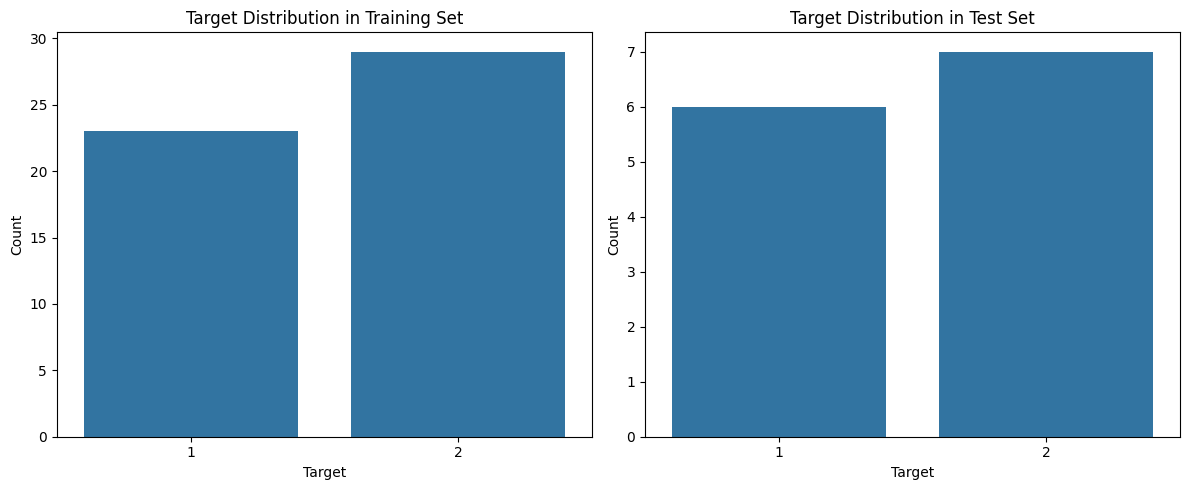

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot y_train distribution
sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title('Target Distribution in Training Set')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Count')

# Plot y_test distribution
sns.countplot(x=y_test, ax=axes[1])
axes[1].set_title('Target Distribution in Test Set')
axes[1].set_xlabel('Target')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()